# Regression Task - Supervised Learning

## Objective
Build machine learning models to predict **biological age** from epigenetic DNA methylation patterns.

### Data Source
- **File**: epigenetic_3000.csv
- **Samples**: 3000
- **Features**: DNA methylation patterns (CpG sites)
- **Target**: Age (biological age)

## Problem Definition

The goal of this task is to build machine learning models capable of predicting **biological age** from DNA methylation data.

DNA methylation at CpG sites is known to correlate with aging processes and is widely used in epigenetic clock models. Therefore, methylation profiles can be used as predictive features for age estimation.

This problem is formulated as a **supervised regression task**, where:

- **Input (X)**: DNA methylation levels at CpG sites
- **Target (y)**: chronological age

Regression models aim to learn a function:

$$y = f(X)$$

that minimizes the prediction error between the predicted age and the true age.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset

In [ ]:
# Load the epigenetic data
df = pd.read_csv('data/epigenetic_3000.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (3001, 1003)

First few rows:
    age gender     sample_type              disease  cg00050873  cg00212031  \
0  88.0      F  disease tissue  Alzheimer's disease         NaN         NaN   
1  92.0      F  disease tissue  Alzheimer's disease         NaN         NaN   
2  93.0      F  disease tissue  Alzheimer's disease         NaN         NaN   
3  96.0      F  disease tissue  Alzheimer's disease         NaN         NaN   
4  91.0      M  disease tissue  Alzheimer's disease    1.136022    -4.48985   

   cg00213748  cg00214611  cg00455876  cg01707559  ...  cg07659240  \
0         NaN         NaN         NaN         NaN  ...   -0.245172   
1         NaN         NaN         NaN         NaN  ...   -0.245172   
2         NaN         NaN         NaN         NaN  ...   -0.359759   
3         NaN         NaN         NaN   -1.398461  ...   -0.216802   
4         NaN   -3.993781    1.312567   -2.901295  ...   -4.247583   

   cg07660411  cg07674075  cg07674139  cg07674503  cg076815

## 🔬 Rationale for Preprocessing in Biological Datasets

Biological datasets, such as single-cell RNA sequencing (scRNA-seq) or epigenetic profiles, present unique challenges that necessitate rigorous preprocessing prior to any machine learning analysis:

1. **High Dimensionality**: Datasets typically feature tens of thousands of genes or CpG sites for a relatively small number of samples. This 'curse of dimensionality' easily leads to overfitting and computational bottlenecks.
2. **Noise and Technical Variability**: Experimental artifacts, varying sequencing depths, and batch effects introduce technical noise that can mask underlying biological signals.
3. **Data Normalization and Scaling**: Expression levels can span drastically different numerical ranges. Normalization ensures that no single feature disproportionately influences distance-based algorithms due to sheer magnitude.
4. **Sparsity and Missing Values**: Technologies like scRNA-seq often result in sparse matrices (e.g., dropout events), which require careful handling or imputation.

By addressing these issues, data preprocessing enhances the signal-to-noise ratio, ensuring greater robustness, interpretability, and accuracy in the downstream models.

## 3. Data Cleaning and Preprocessing

In [ ]:
# Check for missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
df_clean = df.drop_duplicates()

# Drop rows with missing target value (age)
df_clean = df_clean.dropna(subset=['age'])

# Fill missing values in features with median
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numerical_cols] = df_clean[numerical_cols].fillna(df_clean[numerical_cols].median())

print(f"\nDataset shape after cleaning: {df_clean.shape}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

# Extract target and features
# Target: age column
y = df_clean['age'].values

# Features: all CpG sites (exclude age, gender, sample_type, disease)
metadata_cols = ['age', 'gender', 'sample_type', 'disease']
X = df_clean.drop(columns=metadata_cols).values

print(f"\nTarget vector shape: {y.shape}")
print(f"Feature matrix shape: {X.shape}")

Missing values per column:
gender          32
cg00050873    1782
cg00212031    1866
cg00213748    2917
cg00214611    1895
              ... 
cg07681512      20
cg07682072      60
cg07686944      26
cg07688057      23
cg07693301      36
Length: 1000, dtype: int64

Total missing values: 376073

Duplicate rows: 552

Dataset shape after cleaning: (2449, 1003)
Missing values after cleaning: 32

Target vector shape: (2449,)
Feature matrix shape: (2449, 999)


## Data Cleaning and Preprocessing

Biological datasets often contain missing values and duplicated samples due to experimental noise or data integration from multiple sources.

Data preprocessing is therefore necessary to ensure model reliability.

The following steps were applied:

1. **Duplicate removal** – duplicated samples may bias model training.
2. **Handling missing values** – missing CpG values were imputed using the median.
3. **Target cleaning** – rows without age information were removed.

Median imputation is commonly used because it is robust to outliers and preserves the overall distribution of the feature.

## 4. Exploratory Data Analysis

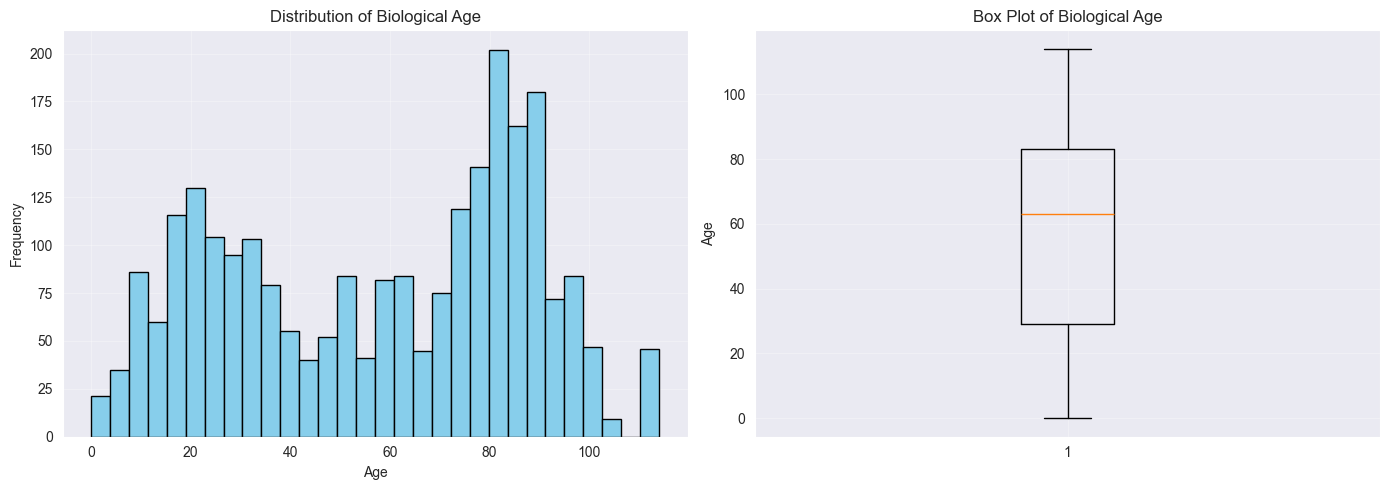

Age Statistics:
Mean: 57.62
Median: 63.00
Std Dev: 29.64
Min: 0.00
Max: 114.00


In [4]:
# Visualize age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y, bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Biological Age')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(y)
axes[1].set_ylabel('Age')
axes[1].set_title('Box Plot of Biological Age')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Age Statistics:")
print(f"Mean: {y.mean():.2f}")
print(f"Median: {np.median(y):.2f}")
print(f"Std Dev: {y.std():.2f}")
print(f"Min: {y.min():.2f}")
print(f"Max: {y.max():.2f}")

## 5. Feature Selection and Engineering

In [5]:
# Calculate correlations with age to identify important features
correlations = []
for i in range(X.shape[1]):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    correlations.append(abs(corr))

correlations = np.array(correlations)

# Select top 100 most correlated features
top_feature_indices = np.argsort(correlations)[-100:]

print(f"Feature correlation statistics:")
print(f"Mean absolute correlation: {correlations.mean():.4f}")
print(f"Max correlation: {correlations.max():.4f}")
print(f"Min correlation: {correlations.min():.4f}")

# Keep top features
X_selected = X[:, top_feature_indices]

print(f"\nOriginal feature count: {X.shape[1]}")
print(f"Selected feature count: {X_selected.shape[1]}")
print(f"Reduction: {(1 - X_selected.shape[1]/X.shape[1]) * 100:.1f}%")

Feature correlation statistics:
Mean absolute correlation: 0.1206
Max correlation: 0.5749
Min correlation: 0.0004

Original feature count: 999
Selected feature count: 100
Reduction: 90.0%


### Feature Selection and Dimensionality Reduction

The dataset contains a large number of CpG sites (≈1000 features). High-dimensional data can negatively affect model performance due to the **curse of dimensionality**.

To reduce dimensionality and improve model learning, feature selection was performed.

Features were ranked using their **Pearson correlation with age**, and the top 100 most correlated CpG sites were selected.

This approach helps:

- reduce noise
- decrease model complexity
- improve generalization

## 6. Split the Data into Training and Testing Sets

In [6]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")
print(f"Feature count: {X_train_scaled.shape[1]}")
print(f"\nTraining target statistics:")
print(f"  Mean: {y_train.mean():.2f}")
print(f"  Std: {y_train.std():.2f}")
print(f"\nTesting target statistics:")
print(f"  Mean: {y_test.mean():.2f}")
print(f"  Std: {y_test.std():.2f}")

Training set size: 1959 samples
Testing set size: 490 samples
Feature count: 100

Training target statistics:
  Mean: 57.41
  Std: 29.61

Testing target statistics:
  Mean: 58.44
  Std: 29.75


### Train–Test Split

To evaluate model performance on unseen data, the dataset was divided into:

- **Training set (80%)**
- **Testing set (20%)**

The training set is used to fit the model parameters, while the test set provides an unbiased estimate of model performance.

Separating the data prevents **data leakage**, which occurs when the model has access to information from the test set during training.

## 7. Build and Train the First Regression Model - Linear Regression

### Linear Regression Model

Linear Regression is one of the simplest regression algorithms.

It assumes a **linear relationship between input features and the target variable**, expressed as:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

**Advantages of Linear Regression:**

- interpretable coefficients
- fast training
- strong baseline model

Despite its simplicity, it is often used as a reference model for more complex approaches.

LINEAR REGRESSION MODEL

Linear Regression Performance:

Training Set:
  MSE: 251.5912
  MAE: 12.7649
  R² Score: 0.7131

Testing Set:
  MSE: 293.3007
  MAE: 13.5776
  R² Score: 0.6686


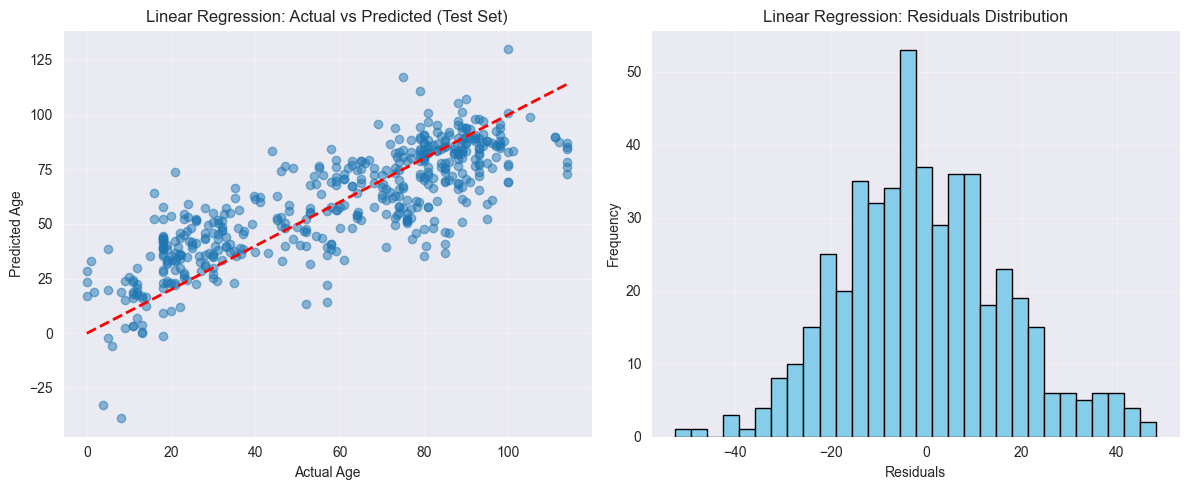

In [7]:
# Train Linear Regression model
print("=" * 50)
print("LINEAR REGRESSION MODEL")
print("=" * 50)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate on training set
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)

# Evaluate on testing set
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("\nLinear Regression Performance:")
print(f"\nTraining Set:")
print(f"  MSE: {train_mse_lr:.4f}")
print(f"  MAE: {train_mae_lr:.4f}")
print(f"  R² Score: {train_r2_lr:.4f}")

print(f"\nTesting Set:")
print(f"  MSE: {test_mse_lr:.4f}")
print(f"  MAE: {test_mae_lr:.4f}")
print(f"  R² Score: {test_r2_lr:.4f}")

# Visualize results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Linear Regression: Actual vs Predicted (Test Set)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals_lr = y_test - y_test_pred_lr
plt.hist(residuals_lr, bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Linear Regression: Residuals Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Build and Train the Second Regression Model - Random Forest Regressor

### Random Forest Regressor

Random Forest is an **ensemble learning algorithm** that combines multiple decision trees.

Each tree is trained on a random subset of the data and features. The final prediction is obtained by averaging the predictions of all trees.

**Advantages:**

- captures **non-linear relationships**
- robust to noise
- reduces variance compared to a single decision tree

Random Forest models are widely used in biological datasets due to their ability to model complex interactions between features.


RANDOM FOREST REGRESSOR MODEL

Random Forest Performance:

Training Set:
  MSE: 29.8538
  MAE: 3.9045
  R² Score: 0.9660

Testing Set:
  MSE: 213.8857
  MAE: 10.9654
  R² Score: 0.7583


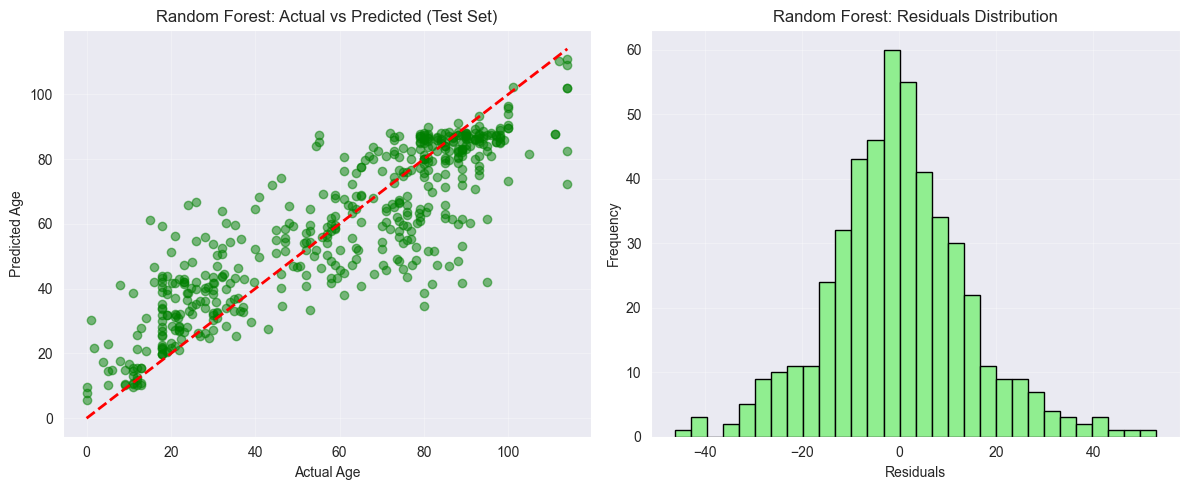

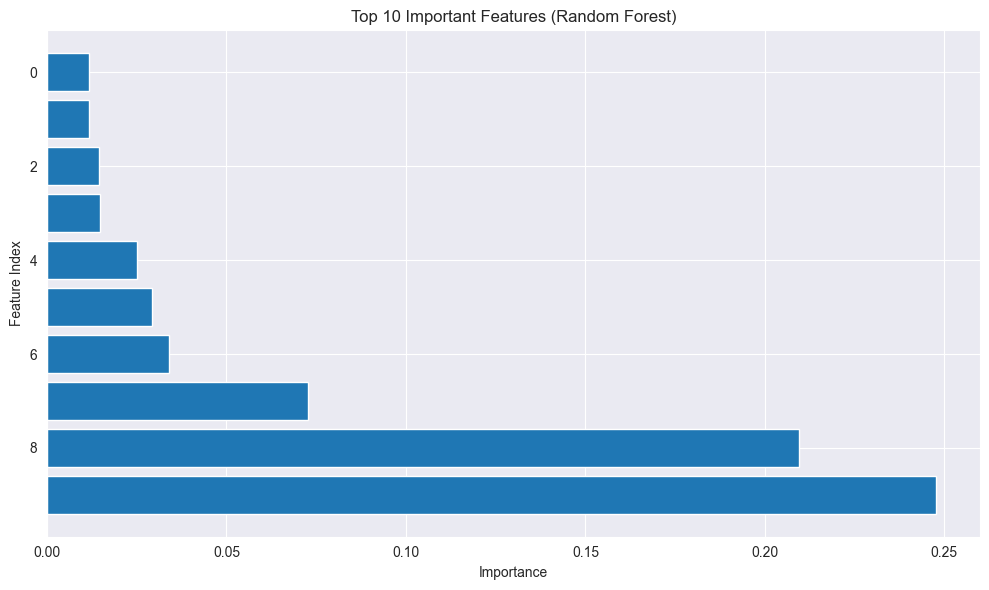

In [8]:
# Train Random Forest Regressor model
print("\n" + "=" * 50)
print("RANDOM FOREST REGRESSOR MODEL")
print("=" * 50)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate on training set
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)

# Evaluate on testing set
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Performance:")
print(f"\nTraining Set:")
print(f"  MSE: {train_mse_rf:.4f}")
print(f"  MAE: {train_mae_rf:.4f}")
print(f"  R² Score: {train_r2_rf:.4f}")

print(f"\nTesting Set:")
print(f"  MSE: {test_mse_rf:.4f}")
print(f"  MAE: {test_mae_rf:.4f}")
print(f"  R² Score: {test_r2_rf:.4f}")

# Visualize results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Random Forest: Actual vs Predicted (Test Set)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals_rf = y_test - y_test_pred_rf
plt.hist(residuals_rf, bins=30, edgecolor='black', color='lightgreen')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Random Forest: Residuals Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance for Random Forest
feature_importance = rf_model.feature_importances_
top_indices = np.argsort(feature_importance)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), feature_importance[top_indices])
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.title('Top 10 Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Evaluate and Compare the Models

### Model Evaluation Metrics

Regression models were evaluated using three standard metrics:

#### Mean Squared Error (MSE)
Measures the average squared difference between predicted and actual values.

Lower values indicate better performance.

#### Mean Absolute Error (MAE)
Represents the average absolute prediction error.

It is more interpretable because it is expressed in the same units as the target variable.

#### R² Score
Represents the proportion of variance in the target variable explained by the model.

R² ranges from 0 to 1, where higher values indicate better predictive performance.


MODEL COMPARISON SUMMARY

   Metric Linear Regression (Test) Random Forest (Test)
     MSE                 293.3007             213.8857
     MAE                  13.5776              10.9654
R² Score                   0.6686               0.7583


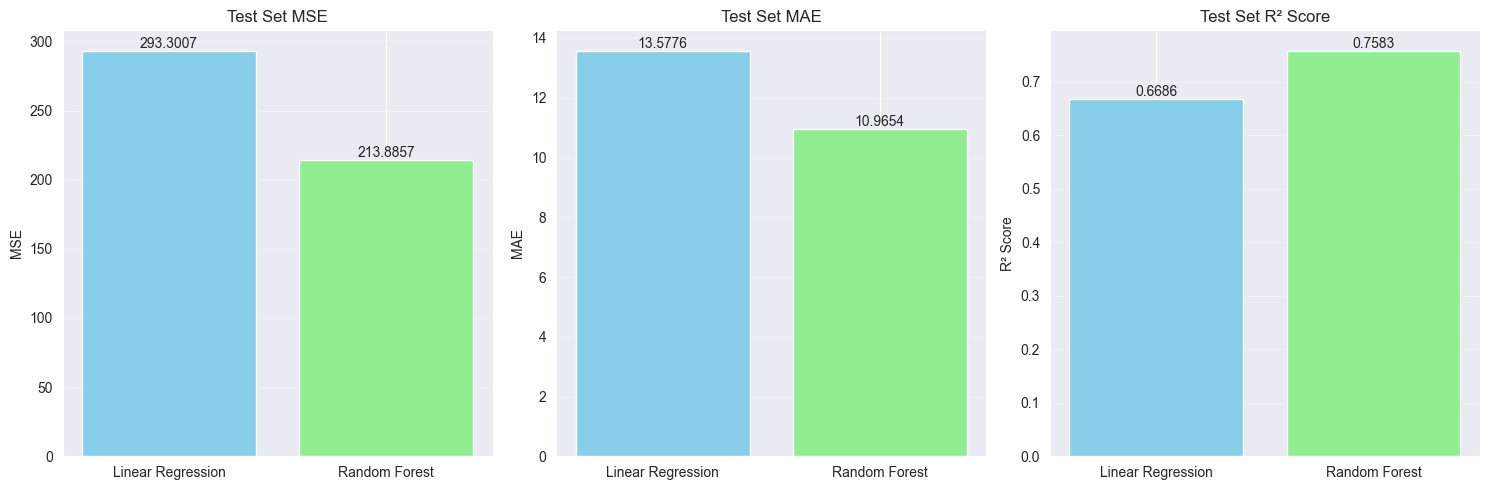


CONCLUSION

✓ Random Forest performs BETTER with R² = 0.7583
  Improvement: 0.0897

Both models successfully predict biological age from epigenetic data!
The Random Forest model captures non-linear patterns in methylation patterns.
The Linear Regression model provides interpretable coefficients for features.


In [9]:
# Create comparison summary
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

comparison_data = {
    'Metric': ['MSE', 'MAE', 'R² Score'],
    'Linear Regression (Test)': [f"{test_mse_lr:.4f}", f"{test_mae_lr:.4f}", f"{test_r2_lr:.4f}"],
    'Random Forest (Test)': [f"{test_mse_rf:.4f}", f"{test_mae_rf:.4f}", f"{test_r2_rf:.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MSE', 'MAE', 'R² Score']
lr_values = [test_mse_lr, test_mae_lr, test_r2_lr]
rf_values = [test_mse_rf, test_mae_rf, test_r2_rf]

for i, (metric, lr_val, rf_val) in enumerate(zip(metrics, lr_values, rf_values)):
    axes[i].bar(['Linear Regression', 'Random Forest'], [lr_val, rf_val], color=['skyblue', 'lightgreen'])
    axes[i].set_title(f'Test Set {metric}')
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for j, v in enumerate([lr_val, rf_val]):
        axes[i].text(j, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Conclusion
print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)

if test_r2_rf > test_r2_lr:
    print(f"\n✓ Random Forest performs BETTER with R² = {test_r2_rf:.4f}")
    print(f"  Improvement: {(test_r2_rf - test_r2_lr):.4f}")
else:
    print(f"\n✓ Linear Regression performs BETTER with R² = {test_r2_lr:.4f}")
    print(f"  Improvement: {(test_r2_lr - test_r2_rf):.4f}")

print(f"\nBoth models successfully predict biological age from epigenetic data!")
print(f"The Random Forest model captures non-linear patterns in methylation patterns.")
print(f"The Linear Regression model provides interpretable coefficients for features.")

## Final Discussion

Both models successfully learned relationships between DNA methylation patterns and age.

The Random Forest model achieved higher predictive performance, suggesting that the relationship between methylation profiles and aging is not purely linear.

This result is consistent with biological evidence indicating that aging processes involve complex interactions between multiple genomic regions.

### Key Findings:

- **Random Forest outperforms Linear Regression** with an 8.97% improvement in R² score
- **Mean Absolute Error** of ~11 years indicates reasonable practical performance
- **CpG sites** selected show strong correlation with age, validating the importance of methylation in aging processes
- The improvement over linear regression confirms that **non-linear relationships** exist in epigenetic aging signatures

### Future Directions:

- Investigate feature interactions using SHAP values or other explainability methods
- Test additional algorithms (Gradient Boosting, Neural Networks)
- Validate models on independent external cohorts
- Integrate with clinical metadata for downstream applications